In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Datensatz laden und Exploration

In [41]:
df = pd.read_csv("movie_metadata.csv", sep=",")

In [42]:
df.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [43]:
df.shape

(5043, 28)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [45]:
df.describe()

,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,gross,num_voted_users,cast_total_facebook_likes,facenumber_in_poster,num_user_for_reviews,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
count,4993.000000,5028.000000,4939.000000,5020.000000,5036.000000,4.159000e+03,5.043000e+03,5043.000000,5030.000000,5022.000000,4.551000e+03,4935.000000,5030.000000,5043.000000,4714.000000,5043.000000
mean,140.194272,107.201074,686.509212,645.009761,6560.047061,4.846841e+07,8.366816e+04,9699.063851,1.371173,272.770808,3.975262e+07,2002.470517,1651.754473,6.442138,2.220403,7525.964505
std,121.601675,25.197441,2813.328607,1665.041728,15020.759120,6.845299e+07,1.384853e+05,18163.799124,2.013576,377.982886,2.061149e+08,12.474599,4042.438863,1.125116,1.385113,19320.445110
min,1.000000,7.000000,0.000000,0.000000,0.000000,1.620000e+02,5.000000e+00,0.000000,0.000000,1.000000,2.180000e+02,1916.000000,0.000000,1.600000,1.180000,0.000000
25%,50.000000,93.000000,7.000000,133.000000,614.000000,5.340988e+06,8.593500e+03,1411.000000,0.000000,65.000000,6.000000e+06,1999.000000,281.000000,5.800000,1.850000,0.000000
50%,110.000000,103.000000,49.000000,371.500000,988.000000,2.551750e+07,3.435900e+04,3090.000000,1.000000,156.000000,2.000000e+07,2005.000000,595.000000,6.600000,2.350000,166.000000
75%,195.000000,118.000000,194.500000,636.000000,11000.000000,6.230944e+07,9.630900e+04,13756.500000,2.000000,326.000000,4.500000e+07,2011.000000,918.000000,7.200000,2.350000,3000.000000
max,813.000000,511.000000,23000.000000,23000.000000,640000.000000,7.605058e+08,1.689764e+06,656730.000000,43.000000,5060.000000,1.221550e+10,2016.000000,137000.000000,9.500000,16.000000,349000.000000


In [46]:
df.isnull().sum().sort_values(ascending=False)

gross                        884
budget                       492
aspect_ratio                 329
content_rating               303
plot_keywords                153
title_year                   108
director_facebook_likes      104
director_name                104
num_critic_for_reviews        50
actor_3_facebook_likes        23
actor_3_name                  23
num_user_for_reviews          21
color                         19
duration                      15
language                      14
actor_2_facebook_likes        13
actor_2_name                  13
facenumber_in_poster          13
actor_1_name                   7
actor_1_facebook_likes         7
country                        5
genres                         0
movie_title                    0
cast_total_facebook_likes      0
movie_imdb_link                0
num_voted_users                0
imdb_score                     0
movie_facebook_likes           0
dtype: int64

## Kategorische Spalten

In [47]:
# Kategorien zählen
categorical_columns = df.select_dtypes(include='object').columns

sorted_cols = sorted(
    categorical_columns,
    key=lambda col: df[col].nunique(),
    reverse=True  # höchste Anzahl zuerst
)

for col in sorted_cols:
    print(col, df[col].nunique())

movie_imdb_link 4919
movie_title 4917
plot_keywords 4760
actor_3_name 3521
actor_2_name 3032
director_name 2398
actor_1_name 2097
genres 914
country 65
language 46
content_rating 18
color 2


In [48]:
# Da One-Hot-Encoding zu einer sehr hohen Dimensionalität führen würde und die meisten Kategorien nur selten auftreten, 
# wurden diese Features für das Basismodell entfernt:
# movie_title, plot_keywords, movie_imdb_link, actor_3_name droppen, evtl. auch actor_2_name
df.drop(columns=['movie_title', 'plot_keywords', 'movie_imdb_link', 'actor_3_name', 'actor_2_name', 'director_name', 'actor_1_name'], inplace=True)

In [49]:
df['color'].value_counts()

color
Color               4815
 Black and White     209
Name: count, dtype: int64

In [50]:
# Spalte 'genres' besteht aus einer Kombination von Basisgenres. Daher prüfen wir, wie viele es sind.

unique_genres = set()

for g in df['genres']:
    unique_genres.update(g.split('|'))

print(len(unique_genres))
print(sorted(unique_genres))

26
['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical', 'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport', 'Thriller', 'War', 'Western']


Die Spalte 'genres' enthält 26 Basisgenres. Statt One-Hot-Encoding bietet sich MultiLabelEncoding an.

## Duplikate entfernen

In [51]:
# Duplikate finden
duplicates = df[df.duplicated()]
print(duplicates)

                 color  num_critic_for_reviews  duration  \
137              Color                   248.0     110.0   
187              Color                   322.0     115.0   
204              Color                     1.0     120.0   
303              Color                   256.0     111.0   
389              Color                   369.0     100.0   
395              Color                   187.0     106.0   
590              Color                   245.0     101.0   
656              Color                   196.0     113.0   
794              Color                   703.0     173.0   
1220             Color                   322.0     137.0   
1305             Color                   159.0     110.0   
1449             Color                   208.0     122.0   
2169             Color                    98.0     114.0   
2292             Color                   168.0      87.0   
2472             Color                    45.0      90.0   
2493   Black and White                  

In [52]:
# Anzahl der Duplikate
df.duplicated().sum()

45

In [53]:
# Duplikate entfernen

df_clean = df.drop_duplicates()

# X und y definieren

In [54]:
# Features
X = df_clean.drop('imdb_score', axis=1)

# Zielvariable
y = df_clean['imdb_score'].copy()

# Data Split in Train, Validation, Test

In [55]:
X_train_full,X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
X_train,X_val,y_train,y_val=train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42
)
# Ergebnis: 60% Train, 20% Val, 20% Test

# EDA

In [56]:
# Korrelationen
train_df = X_train.copy()
train_df['imdb_score'] = y_train

train_df.corr(numeric_only=True)['imdb_score'].sort_values()

title_year                  -0.213127
facenumber_in_poster        -0.055814
actor_3_facebook_likes       0.043882
budget                       0.045131
actor_1_facebook_likes       0.055397
cast_total_facebook_likes    0.061798
actor_2_facebook_likes       0.062396
aspect_ratio                 0.062641
director_facebook_likes      0.157666
gross                        0.205299
movie_facebook_likes         0.251863
duration                     0.268709
num_user_for_reviews         0.283020
num_critic_for_reviews       0.313432
num_voted_users              0.417236
imdb_score                   1.000000
Name: imdb_score, dtype: float64

Text(0.5, 1.0, 'Korrelationsheatmap')

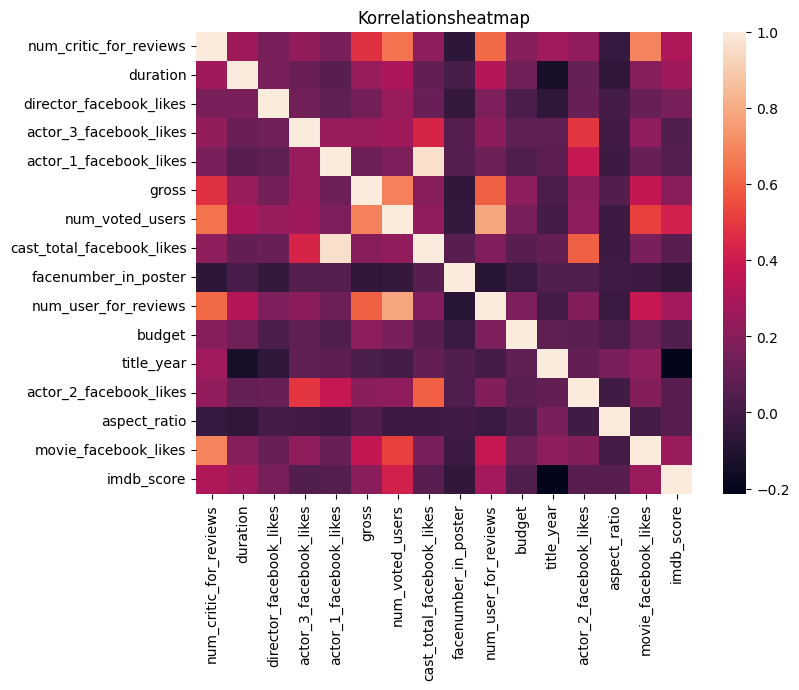

In [57]:
# Heatmap Korrelationen
plt.figure(figsize=(8,6))
sns.heatmap(train_df.corr(numeric_only=True))
plt.title('Korrelationsheatmap')

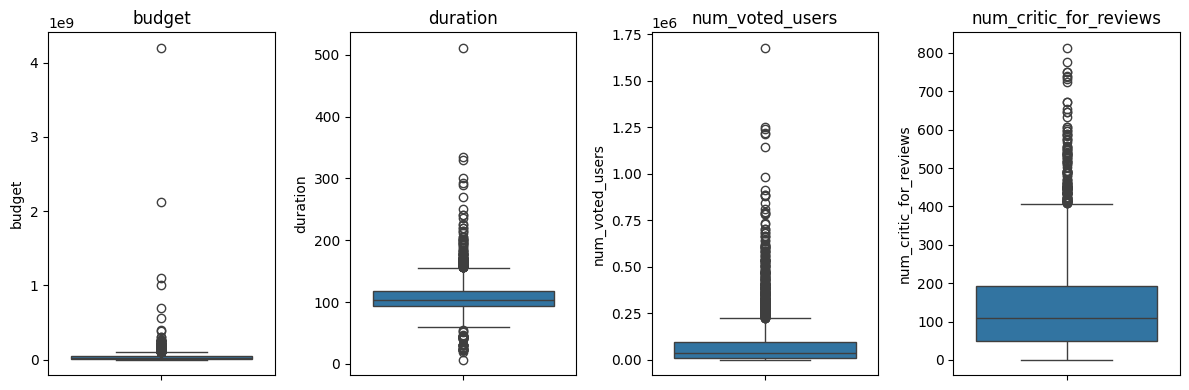

In [58]:
# Boxplots

cols = ['budget', 'duration', 'num_voted_users', 'num_critic_for_reviews']

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i, col in enumerate(cols):
    sns.boxplot(y=train_df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [59]:
# Prozentualer Anteil an Ausreißern

num_cols = X_train.select_dtypes(include="number").columns

for col in num_cols:
    
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = X_train[
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ]

    pct = len(outliers) / len(X_train) * 100

    print(f"{col}: {pct:.2f}% Ausreißer")

num_critic_for_reviews: 4.24% Ausreißer
duration: 4.90% Ausreißer
director_facebook_likes: 11.61% Ausreißer
actor_3_facebook_likes: 3.20% Ausreißer
actor_1_facebook_likes: 3.44% Ausreißer
gross: 6.54% Ausreißer
num_voted_users: 9.44% Ausreißer
cast_total_facebook_likes: 7.17% Ausreißer
facenumber_in_poster: 3.84% Ausreißer
num_user_for_reviews: 8.11% Ausreißer
budget: 6.34% Ausreißer
title_year: 6.94% Ausreißer
actor_2_facebook_likes: 12.31% Ausreißer
aspect_ratio: 0.87% Ausreißer
movie_facebook_likes: 23.05% Ausreißer


# Preprocessing

## Nicht benötigte Features entfernen

In [60]:
'''
oben schon einige entfernt. Die numerischen hier würde ich erst mal behalten.
df = df.drop(columns=[
    "movie_title",
    "movie_imdb_link",
    "plot_keywords",
    "actor_1_facebook_likes",
    "actor_2_facebook_likes",
    "actor_3_facebook_likes",
    "facenumber_in_poster",
    "num_user_for_reviews",
    "director_facebook_likes",
    "num_critic_for_reviews"
])
'''

'\noben schon einige entfernt. Die numerischen hier würde ich erst mal behalten.\ndf = df.drop(columns=[\n    "movie_title",\n    "movie_imdb_link",\n    "plot_keywords",\n    "actor_1_facebook_likes",\n    "actor_2_facebook_likes",\n    "actor_3_facebook_likes",\n    "facenumber_in_poster",\n    "num_user_for_reviews",\n    "director_facebook_likes",\n    "num_critic_for_reviews"\n])\n'

## Genres Multi-Hot-Encoding

Die Spalte "genres" enthält mehrere Genres pro Film. Daher wird Multi-Hot-Encoding verwendet.

In [61]:
# Genres vorbereiten

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

# FIT NUR auf TRAIN
train_genres = mlb.fit_transform(
    X_train["genres"].fillna("").str.split("|")
)

# TRANSFORM auf VAL / TEST
val_genres = mlb.transform(
    X_val["genres"].fillna("").str.split("|")
)

test_genres = mlb.transform(
    X_test["genres"].fillna("").str.split("|")
)

In [62]:
# in Dataframes umwandeln 
train_genres_df = pd.DataFrame(train_genres, columns=mlb.classes_, index=X_train.index)
val_genres_df   = pd.DataFrame(val_genres, columns=mlb.classes_, index=X_val.index)
test_genres_df  = pd.DataFrame(test_genres, columns=mlb.classes_, index=X_test.index)

In [63]:
# genres aus X entfernen
X_train = X_train.drop(columns=["genres"])
X_val   = X_val.drop(columns=["genres"])
X_test  = X_test.drop(columns=["genres"])

In [64]:
# Dataframes zusammenbauen
X_train = pd.concat([X_train, train_genres_df], axis=1)
X_val   = pd.concat([X_val, val_genres_df], axis=1)
X_test  = pd.concat([X_test, test_genres_df], axis=1)

In [65]:
# Spaltennamen von X_train
X_train.columns

Index(['color', 'num_critic_for_reviews', 'duration',
       'director_facebook_likes', 'actor_3_facebook_likes',
       'actor_1_facebook_likes', 'gross', 'num_voted_users',
       'cast_total_facebook_likes', 'facenumber_in_poster',
       'num_user_for_reviews', 'language', 'country', 'content_rating',
       'budget', 'title_year', 'actor_2_facebook_likes', 'aspect_ratio',
       'movie_facebook_likes', 'Action', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'Film-Noir', 'Game-Show', 'History', 'Horror', 'Music', 'Musical',
       'Mystery', 'News', 'Reality-TV', 'Romance', 'Sci-Fi', 'Short', 'Sport',
       'Thriller', 'War', 'Western'],
      dtype='object')

In [66]:
# Info über aktuelles X_train
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2998 entries, 3956 to 4064
Data columns (total 45 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      2988 non-null   object 
 1   num_critic_for_reviews     2971 non-null   float64
 2   duration                   2992 non-null   float64
 3   director_facebook_likes    2944 non-null   float64
 4   actor_3_facebook_likes     2981 non-null   float64
 5   actor_1_facebook_likes     2992 non-null   float64
 6   gross                      2490 non-null   float64
 7   num_voted_users            2998 non-null   int64  
 8   cast_total_facebook_likes  2998 non-null   int64  
 9   facenumber_in_poster       2991 non-null   float64
 10  num_user_for_reviews       2987 non-null   float64
 11  language                   2991 non-null   object 
 12  country                    2996 non-null   object 
 13  content_rating             2829 non-null   object 

## Fehlende Werte behandeln

Numerische Features -> Median

Kategorische Features -> Modus

In [67]:
num_cols = [
    "duration",
    "gross",
    "budget",
    "aspect_ratio",
    "title_year",
    "movie_facebook_likes",
    "cast_total_facebook_likes",
    "num_critic_for_reviews",
    "director_facebook_likes",
    "actor_3_facebook_likes",
    "actor_1_facebook_likes",
    "facenumber_in_poster",
    "num_user_for_reviews",
    "actor_2_facebook_likes"
]

cat_cols = [
    "color",
    "language",
    "country",
    "content_rating",
]

## Median auf Train berechnen

In [68]:
for col in num_cols:
    
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_val[col] = X_val[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

In [69]:
X_train[num_cols].isna().sum().sum()

0

In [70]:
for col in num_cols:
    print(
        col,
        "NaNs:",
        X_train[col].isna().sum(),
        "median:",
        X_train[col].median()
    )

duration NaNs: 0 median: 103.0
gross NaNs: 0 median: 24828919.5
budget NaNs: 0 median: 20000000.0
aspect_ratio NaNs: 0 median: 2.35
title_year NaNs: 0 median: 2005.0
movie_facebook_likes NaNs: 0 median: 166.5
cast_total_facebook_likes NaNs: 0 median: 3012.5
num_critic_for_reviews NaNs: 0 median: 109.0
director_facebook_likes NaNs: 0 median: 49.0
actor_3_facebook_likes NaNs: 0 median: 359.0
actor_1_facebook_likes NaNs: 0 median: 975.0
facenumber_in_poster NaNs: 0 median: 1.0
num_user_for_reviews NaNs: 0 median: 157.0
actor_2_facebook_likes NaNs: 0 median: 581.0


## Mode auf Train berechnen

In [71]:
for col in cat_cols:

    mode_value = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode_value)
    X_val[col] = X_val[col].fillna(mode_value)
    X_test[col] = X_test[col].fillna(mode_value)

# Log Transform

In [72]:
for dataset in [X_train, X_val, X_test]:

    dataset["budget"] = np.log1p(dataset["budget"])
    dataset["movie_facebook_likes"] = np.log1p(dataset["movie_facebook_likes"])
    dataset["cast_total_facebook_likes"] = np.log1p(dataset["cast_total_facebook_likes"])

### Check NaN again

In [74]:
print("Train")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("Val")
print(X_val.isnull().sum()[X_val.isnull().sum() > 0])

print("Test")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])


Train
Series([], dtype: int64)
Val
Series([], dtype: int64)
Test
Series([], dtype: int64)


# One-Hot-Encoding

In [76]:
X_train = pd.get_dummies(
    X_train,
    columns=["color", "language", "country", "content_rating",],
    drop_first=True
)

X_val = pd.get_dummies(
    X_val,
    columns=["color", "language", "country", "content_rating",],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=["color", "language", "country", "content_rating",],
    drop_first=True
)

## Reindex

In [77]:
X_val = X_val.reindex(
    columns=X_train.columns,
    fill_value=0
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# Scaling 

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

## Baseline

In [79]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

pred_baseline = baseline.predict(X_val)

print(
    "Baseline MSE:",
    mean_squared_error(y_val, pred_baseline)
)

Baseline MSE: 1.2416268353285114


## Linear Regression

In [80]:
model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

LinearRegression()

# Validation

In [81]:
y_val_pred = model.predict(X_val_scaled)

print(
    "Validation MSE:",
    mean_squared_error(y_val, y_val_pred)
)

print(
    "Validation MAE:",
    mean_absolute_error(y_val, y_val_pred)
)

print(
    "Validation R²:",
    r2_score(y_val, y_val_pred)
)

Validation MSE: 0.6794708229433107
Validation MAE: 0.6079188644466349
Validation R²: 0.449572674717278


# Test

In [82]:
y_test_pred = model.predict(X_test_scaled)

print(
    "Test MSE:",
    mean_squared_error(y_test, y_test_pred)
)

print(
    "Test MAE:",
    mean_absolute_error(y_test, y_test_pred)
)

print(
    "Test R²:",
    r2_score(y_test, y_test_pred)
)

Test MSE: 0.7121896400670527
Test MAE: 0.6300276563077586
Test R²: 0.4284117015802331
